In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rasterio geopandas shapely

In [ ]:
import os

base = "/content/drive/MyDrive"

for root, dirs, files in os.walk(base):
    if "BAND2.tif" in files or "BAND3.tif" in files:
        print(root)

/content/drive/MyDrive/Python Project/LISS3_Dehradun/scene_049
/content/drive/MyDrive/Python Project/LISS3_Dehradun/scene_050


In [ ]:
import os

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"

for scene in ["scene_049", "scene_050"]:
    folder = os.path.join(base, scene)

    print("\n", "="*60)
    print(scene)
    print("="*60)

    for f in sorted(os.listdir(folder)):
        print(f)


scene_049
BAND2.tif
BAND3.tif
BAND4.tif
BAND5.tif
BAND_META.txt
R2314JUL2026079056009600049PSANSTUCSRHTDF.jpg
R2314JUL2026079056009600049PSANSTUCSRHTDF.meta

scene_050
BAND2.tif
BAND3.tif
BAND4.tif
BAND5.tif
BAND_META.txt
R2314JUL2026079056009600050PSANSTUCSRHTDF.jpg
R2314JUL2026079056009600050PSANSTUCSRHTDF.meta


In [ ]:
import os

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"

for root, dirs, files in os.walk(base):
    for file in files:
        if file.lower().endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun.zip


In [ ]:
import zipfile
import os

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"
zip_path = os.path.join(base, "Dehradun.zip")

extract_dir = os.path.join(base, "Dehradun_boundary")

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:")
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))

Extracted files:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.shx
/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.cpg
/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.dbf
/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.prj
/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.qmd
/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.shp


In [ ]:
import rasterio
import os

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"

for scene in ["scene_049", "scene_050"]:
    print("\n" + "="*50)
    print(scene)
    print("="*50)

    for band in ["BAND2", "BAND3", "BAND4", "BAND5"]:
        path = os.path.join(base, scene, f"{band}.tif")

        with rasterio.open(path) as src:
            print(
                band,
                "| CRS:", src.crs,
                "| Resolution:", src.res,
                "| Shape:", src.shape,
                "| Bounds:", src.bounds
            )


scene_049
BAND2 | CRS: EPSG:32644 | Resolution: (24.0, 24.0) | Shape: (7080, 7974) | Bounds: BoundingBox(left=132337.44308370308, bottom=3345084.0, right=323713.44308370305, top=3515004.0)
BAND3 | CRS: EPSG:32644 | Resolution: (24.0, 24.0) | Shape: (7080, 7974) | Bounds: BoundingBox(left=132337.44308370308, bottom=3345084.0, right=323713.44308370305, top=3515004.0)
BAND4 | CRS: EPSG:32644 | Resolution: (24.0, 24.0) | Shape: (7080, 7974) | Bounds: BoundingBox(left=132337.44308370308, bottom=3345084.0, right=323713.44308370305, top=3515004.0)
BAND5 | CRS: EPSG:32644 | Resolution: (24.0, 24.0) | Shape: (7080, 7974) | Bounds: BoundingBox(left=132337.44308370308, bottom=3345084.0, right=323713.44308370305, top=3515004.0)

scene_050
BAND2 | CRS: EPSG:32643 | Resolution: (24.0, 24.0) | Shape: (7482, 7606) | Bounds: BoundingBox(left=681553.443083703, bottom=3208788.0, right=864097.443083703, top=3388356.0)
BAND3 | CRS: EPSG:32643 | Resolution: (24.0, 24.0) | Shape: (7482, 7606) | Bounds: Boun

In [ ]:
import os
import rasterio

from rasterio.warp import calculate_default_transform, reproject, Resampling

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"

scene_050 = os.path.join(base, "scene_050")
reprojected_dir = os.path.join(base, "reprojected_32644")

os.makedirs(reprojected_dir, exist_ok=True)

target_crs = "EPSG:32644"

for band in ["BAND2", "BAND3", "BAND4", "BAND5"]:

    input_path = os.path.join(scene_050, f"{band}.tif")
    output_path = os.path.join(
        reprojected_dir,
        f"{band}_scene050_32644.tif"
    )

    with rasterio.open(input_path) as src:

        transform, width, height = calculate_default_transform(
            src.crs,
            target_crs,
            src.width,
            src.height,
            *src.bounds
        )

        profile = src.profile.copy()

        profile.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height
        })

        with rasterio.open(output_path, "w", **profile) as dst:

            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest
            )

    print(f"Done: {band}")
    print(output_path)

Done: BAND2
/content/drive/MyDrive/Python Project/LISS3_Dehradun/reprojected_32644/BAND2_scene050_32644.tif


Done: BAND3
/content/drive/MyDrive/Python Project/LISS3_Dehradun/reprojected_32644/BAND3_scene050_32644.tif


Done: BAND4
/content/drive/MyDrive/Python Project/LISS3_Dehradun/reprojected_32644/BAND4_scene050_32644.tif
Done: BAND5
/content/drive/MyDrive/Python Project/LISS3_Dehradun/reprojected_32644/BAND5_scene050_32644.tif


In [ ]:
import os
import glob
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd

# ============================================================
# PATHS
# ============================================================

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"

scene_049 = os.path.join(base, "scene_049")
reprojected_dir = os.path.join(base, "reprojected_32644")

shapefile = os.path.join(
    base,
    "Dehradun_boundary",
    "Dehradun.shp"
)

output_dir = os.path.join(base, "processed")
os.makedirs(output_dir, exist_ok=True)

target_crs = "EPSG:32644"


# ============================================================
# LOAD DEHRADUN BOUNDARY
# ============================================================

gdf = gpd.read_file(shapefile)

print("Original boundary CRS:", gdf.crs)

# Reproject boundary to raster CRS
gdf = gdf.to_crs(target_crs)

print("Boundary CRS for processing:", gdf.crs)


# ============================================================
# PROCESS EACH BAND
# ============================================================

for band in ["BAND2", "BAND3", "BAND4", "BAND5"]:

    print("\n" + "=" * 60)
    print(f"PROCESSING {band}")
    print("=" * 60)

    # --------------------------------------------------------
    # Scene 049 - already EPSG:32644
    # --------------------------------------------------------

    file_049 = os.path.join(
        scene_049,
        f"{band}.tif"
    )

    # --------------------------------------------------------
    # Scene 050 - already reprojected to EPSG:32644
    # --------------------------------------------------------

    file_050 = os.path.join(
        reprojected_dir,
        f"{band}_scene050_32644.tif"
    )

    print("Scene 049:", file_049)
    print("Scene 050:", file_050)

    # --------------------------------------------------------
    # Open rasters
    # --------------------------------------------------------

    src1 = rasterio.open(file_049)
    src2 = rasterio.open(file_050)

    print("CRS 049:", src1.crs)
    print("CRS 050:", src2.crs)

    # --------------------------------------------------------
    # MOSAIC
    # --------------------------------------------------------

    mosaic, mosaic_transform = merge(
        [src1, src2],
        res=(24, 24)
    )

    print("Mosaic shape:", mosaic.shape)

    # --------------------------------------------------------
    # Mosaic metadata
    # --------------------------------------------------------

    mosaic_meta = src1.meta.copy()

    mosaic_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": mosaic_transform,
        "crs": target_crs,
        "count": 1,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "compress": "deflate"
    })

    # --------------------------------------------------------
    # Save mosaic
    # --------------------------------------------------------

    mosaic_path = os.path.join(
        output_dir,
        f"{band}_mosaic_32644.tif"
    )

    with rasterio.open(
        mosaic_path,
        "w",
        **mosaic_meta
    ) as dst:

        dst.write(mosaic)

    print("Mosaic saved:")
    print(mosaic_path)

    src1.close()
    src2.close()

    # --------------------------------------------------------
    # CLIP TO DEHRADUN
    # --------------------------------------------------------

    with rasterio.open(mosaic_path) as src:

        clipped, clipped_transform = mask(
            src,
            gdf.geometry,
            crop=True
        )

        clipped_meta = src.meta.copy()

        clipped_meta.update({
            "driver": "GTiff",
            "height": clipped.shape[1],
            "width": clipped.shape[2],
            "transform": clipped_transform,
            "crs": target_crs,
            "count": 1,
            "tiled": True,
            "blockxsize": 256,
            "blockysize": 256,
            "compress": "deflate"
        })

        output_path = os.path.join(
            output_dir,
            f"{band}_Dehradun.tif"
        )

        with rasterio.open(
            output_path,
            "w",
            **clipped_meta
        ) as dst:

            dst.write(clipped)

    print("Clipped successfully:")
    print(output_path)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 60)
print("FINAL DEHRADUN LISS-3 DATASETS")
print("=" * 60)

for file in sorted(
    glob.glob(
        os.path.join(output_dir, "*_Dehradun.tif")
    )
):
    print(file)

Original boundary CRS: EPSG:4326
Boundary CRS for processing: EPSG:32644

PROCESSING BAND2
Scene 049: /content/drive/MyDrive/Python Project/LISS3_Dehradun/scene_049/BAND2.tif
Scene 050: /content/drive/MyDrive/Python Project/LISS3_Dehradun/reprojected_32644/BAND2_scene050_32644.tif
CRS 049: EPSG:32644
CRS 050: EPSG:32644
Mosaic shape: (1, 12911, 9450)
Mosaic saved:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND2_mosaic_32644.tif
Clipped successfully:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND2_Dehradun.tif

PROCESSING BAND3
Scene 049: /content/drive/MyDrive/Python Project/LISS3_Dehradun/scene_049/BAND3.tif
Scene 050: /content/drive/MyDrive/Python Project/LISS3_Dehradun/reprojected_32644/BAND3_scene050_32644.tif
CRS 049: EPSG:32644
CRS 050: EPSG:32644
Mosaic shape: (1, 12911, 9450)
Mosaic saved:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND3_mosaic_32644.tif
Clipped successfully:
/content/drive/MyDrive/Python Project/LIS

In [ ]:
import rasterio
import os

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed"

for band in ["BAND2", "BAND3", "BAND4", "BAND5"]:

    path = os.path.join(base, f"{band}_Dehradun.tif")

    with rasterio.open(path) as src:

        print("\n" + "="*60)
        print(band)

        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Width:", src.width)
        print("Height:", src.height)
        print("Data type:", src.dtypes[0])
        print("NoData:", src.nodata)
        print("Bounds:", src.bounds)

        print("Minimum:", src.read(1).min())
        print("Maximum:", src.read(1).max())


BAND2
CRS: EPSG:32644
Resolution: (24.0, 24.0)
Width: 2919
Height: 4792
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)
Minimum: 0
Maximum: 9256

BAND3
CRS: EPSG:32644
Resolution: (24.0, 24.0)
Width: 2919
Height: 4792
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)
Minimum: 0
Maximum: 9533

BAND4
CRS: EPSG:32644
Resolution: (24.0, 24.0)
Width: 2919
Height: 4792
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)
Minimum: 0
Maximum: 10000

BAND5
CRS: EPSG:32644
Resolution: (24.0, 24.0)
Width: 2919
Height: 4792
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)
Minimum: 0
Maximum: 6339


In [ ]:
meta_path = "/content/drive/MyDrive/Python Project/LISS3_Dehradun/scene_049/BAND_META.txt"

with open(meta_path, "r", errors="ignore") as f:
    text = f.read()

print(text)

ProductID=2654170191
OTSProductID=R2314JUL2026079056009600049PSANSTUCSRHTDF
SatID= IRS-R2 
Sensor= L3 
SubScene= -NA- 
GenAgency= NRSC 
Path= 096 
Row= 049 
SegmentNumber= 
SessionNumber= 1 
StripNumber= 
SceneNumber= 
DateOfPass= 14-JUL-2026 
NoOfBands= 4 
BandNumbers= 2345 
PassType= PLD 
DateOfDump= 14-JUL-2026 
DumpingOrbitNo= 079056 
ImagingOrbitNo= 079056 
BytesPerPixel=2
BitsPerPixel= 10 
GenerationDateTime=22-Jul-2026 06:24:38
ProdCode=STUCSRHTD
ProdType=Geophysical
InputResolutionAlong=  23.50 
InputResolutionAcross=  23.50 
OutputResolutionAlong=  24.00 
OutputResolutionAcross=  24.00 
Season= JUL 
ImageFormat= GEOTIFF 
ProcessingLevel=AtmosphericallyCorrectedProduct
ResampCode= CC 
NoScans= 7080 
NoPixels= 7974 
StartPixel= 0 
MapProjection= UTM 
Ellipsoid= WGS_84 
Datum= WGS84 
MapOriginLat=   0.000000 
MapOriginLon=  81.000000 
ProdULLat=  31.711373 
ProdULLon=  77.121120 
ProdURLat=  31.756846 
ProdURLon=  79.138568 
ProdLRLat=  30.224633 
ProdLRLon=  79.168096 
ProdLLLat

In [ ]:
# TRAINING THE MODEL

In [3]:
import os

base = "/content/drive/MyDrive/Python Project/LISS3_Dehradun"

processed = os.path.join(base, "processed")

B2 = os.path.join(processed, "BAND2_Dehradun.tif")
B3 = os.path.join(processed, "BAND3_Dehradun.tif")
B4 = os.path.join(processed, "BAND4_Dehradun.tif")
B5 = os.path.join(processed, "BAND5_Dehradun.tif")

print(B2)
print(B3)
print(B4)
print(B5)

/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND2_Dehradun.tif
/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND3_Dehradun.tif
/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND4_Dehradun.tif
/content/drive/MyDrive/Python Project/LISS3_Dehradun/processed/BAND5_Dehradun.tif


In [17]:
training_path = os.path.join(
    base,
    "/content/drive/MyDrive/Python Project/training_points.gpkg"
)

print(training_path)
print(os.path.exists(training_path))

/content/drive/MyDrive/Python Project/training_points.gpkg
True


In [18]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd

print("rasterio:", rasterio.__version__)
print("geopandas:", gpd.__version__)

rasterio: 1.5.0
geopandas: 1.1.4


In [19]:
training = gpd.read_file(training_path)

print(training.head())
print("\nCRS:", training.crs)
print("\nNumber of polygons:", len(training))
print("\nColumns:")
print(training.columns.tolist())

   classes                        geometry
0        3  POINT (182940.567 3373531.845)
1        3  POINT (184826.069 3374733.853)
2        3   POINT (184439.541 3371044.16)
3        3  POINT (185379.936 3370685.915)
4        3  POINT (194906.436 3370535.075)

CRS: EPSG:32644

Number of polygons: 516

Columns:
['classes', 'geometry']


In [20]:
print(training["classes"].value_counts().sort_index())

classes
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [21]:
raster_paths = {
    "B2": B2,
    "B3": B3,
    "B4": B4,
    "B5": B5
}

coords = [
    (geom.x, geom.y)
    for geom in training.geometry
]

samples = pd.DataFrame({
    "class": training["classes"].astype(int).values
})

for band_name, raster_path in raster_paths.items():

    with rasterio.open(raster_path) as src:
        values = [
            value[0]
            for value in src.sample(coords)
        ]

        samples[band_name] = values

samples = samples[
    ["B2", "B3", "B4", "B5", "class"]
]

print(samples.head(10))
print("\nDataset shape:", samples.shape)

     B2    B3    B4    B5  class
0   908   862   829   351      3
1   834   834   909   426      3
2   882   942  2119  1665      3
3   838   933  2295  1955      3
4   920   959  2191  1908      3
5   815   880  2204  1889      3
6   803   803  1076   575      3
7   863   934  2638  2486      3
8   996  1005  2676  2537      3
9  1368  1451  2768  2226      3

Dataset shape: (516, 5)


In [22]:
csv_path = os.path.join(
    base,
    "LISS3_Dehradun_training_samples.csv"
)

samples.to_csv(csv_path, index=False)

print("CSV saved successfully:")
print(csv_path)

CSV saved successfully:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_training_samples.csv


In [23]:
print(samples.groupby("class")[["B2", "B3", "B4", "B5"]].mean())

               B2          B3           B4           B5
class                                                  
1      865.727273  810.181818  2674.627273  1689.918182
2      644.201923  626.346154  2283.615385  1565.048077
3      832.440000  845.150000  1633.430000  1177.670000
4      882.059406  914.683168  2249.504950  1873.425743
5      692.346535  661.000000  2491.712871  1776.118812


In [24]:
print(samples.groupby("class").size())

class
1    110
2    104
3    100
4    101
5    101
dtype: int64


In [25]:
# Class-wise spectral summary

class_names = {
    1: "Forest",
    2: "Agriculture",
    3: "Water",
    4: "Urban",
    5: "Barren"
}

summary = samples.groupby("class")[["B2", "B3", "B4", "B5"]].mean()

summary.index = summary.index.map(class_names)

print("Mean spectral values by land-cover class:")
display(summary.round(2))

print("\nNumber of samples per class:")
print(samples["class"].map(class_names).value_counts())

Mean spectral values by land-cover class:


,B2,B3,B4,B5
class,,,,
Forest,865.73,810.18,2674.63,1689.92
Agriculture,644.20,626.35,2283.62,1565.05
Water,832.44,845.15,1633.43,1177.67
Urban,882.06,914.68,2249.50,1873.43
Barren,692.35,661.00,2491.71,1776.12



Number of samples per class:
class
Forest         110
Agriculture    104
Barren         101
Urban          101
Water          100
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Features
X = samples[["B2", "B3", "B4", "B5"]]

# Target
y = samples["class"]

print("Features:", X.columns.tolist())
print("Samples:", len(X))

Features: ['B2', 'B3', 'B4', 'B5']
Samples: 516


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 412
Testing samples: 104

Training class distribution:
class
1    88
2    83
3    80
4    80
5    81
Name: count, dtype: int64

Testing class distribution:
class
1    22
2    21
3    20
4    21
5    20
Name: count, dtype: int64


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [30]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.5000


In [ ]:
class_names = [
    "Forest",
    "Agriculture",
    "Water",
    "Urban",
    "Barren"
]

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[1, 2, 3, 4, 5],
        target_names=class_names,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

      Forest       0.75      0.75      0.75        12
 Agriculture       0.67      0.50      0.57        12
       Water       0.57      0.67      0.62        12
       Urban       0.56      0.75      0.64        12
      Barren       0.67      0.50      0.57        12

    accuracy                           0.63        60
   macro avg       0.64      0.63      0.63        60
weighted avg       0.64      0.63      0.63        60



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[9 0 1 0 2]
 [1 6 3 1 1]
 [0 0 8 4 0]
 [0 1 2 9 0]
 [2 2 0 2 6]]


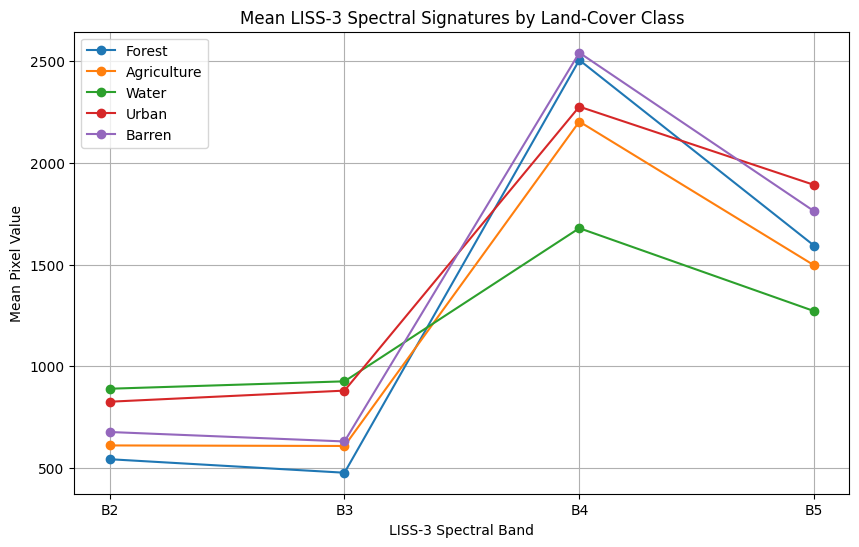

In [ ]:
import matplotlib.pyplot as plt

class_names = {
    1: "Forest",
    2: "Agriculture",
    3: "Water",
    4: "Urban",
    5: "Barren"
}

bands = ["B2", "B3", "B4", "B5"]

plt.figure(figsize=(10, 6))

for class_id, name in class_names.items():

    mean_values = samples[
        samples["class"] == class_id
    ][bands].mean()

    plt.plot(
        bands,
        mean_values,
        marker="o",
        label=name
    )

plt.xlabel("LISS-3 Spectral Band")
plt.ylabel("Mean Pixel Value")
plt.title("Mean LISS-3 Spectral Signatures by Land-Cover Class")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = y_pred

misclassified = results[
    results["actual"] != results["predicted"]
].copy()

misclassified["actual_name"] = (
    misclassified["actual"].map(class_names)
)

misclassified["predicted_name"] = (
    misclassified["predicted"].map(class_names)
)

print(misclassified)

       B2    B3    B4    B5  actual  predicted  actual_name predicted_name
189   560   502  2617  1577       5          1       Barren         Forest
245  2520  2580  3741  2810       1          3       Forest          Water
84    928   935  2566  1846       1          5       Forest         Barren
8     996  1005  2676  2537       3          4        Water          Urban
52   1683  1652  3179  2604       1          5       Forest         Barren
226   704   757  1544  1021       2          3  Agriculture          Water
131   578   585  1680  1460       2          3  Agriculture          Water
165   660   685  2344  1676       5          2       Barren    Agriculture
236   491   476  2558  1516       2          1  Agriculture         Forest
25    940  1083  2555  1899       3          4        Water          Urban
291   916   903  1903  1783       4          3        Urban          Water
128   605   609  2029  1785       2          4  Agriculture          Urban
230   718   715  1647  10

In [ ]:
final_model = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),

    ("scaler", StandardScaler()),

    ("logreg", LogisticRegression(
        C=100,
        class_weight=None,
        solver="lbfgs",
        max_iter=5000
    ))
])

In [4]:
new_training_path = "/content/drive/MyDrive/Python Project/training_points.gpkg"

In [5]:
import geopandas as gpd

training_new = gpd.read_file(new_training_path)

print(training_new.head())

print("\nCRS:", training_new.crs)
print("Number of points:", len(training_new))
print("Columns:", training_new.columns.tolist())

print("\nClass distribution:")
print(training_new["classes"].value_counts().sort_index())

   classes                        geometry
0        3  POINT (182940.567 3373531.845)
1        3  POINT (184826.069 3374733.853)
2        3   POINT (184439.541 3371044.16)
3        3  POINT (185379.936 3370685.915)
4        3  POINT (194906.436 3370535.075)

CRS: EPSG:32644
Number of points: 516
Columns: ['classes', 'geometry']

Class distribution:
classes
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [6]:
import rasterio
import pandas as pd

# LISS-3 raster paths
raster_paths = {
    "B2": B2,
    "B3": B3,
    "B4": B4,
    "B5": B5
}

# Coordinates of the 516 training points
coords = [
    (geom.x, geom.y)
    for geom in training_new.geometry
]

# Create dataframe with class labels
samples_new = pd.DataFrame({
    "class": training_new["classes"].astype(int).values
})

# Extract pixel values from each LISS-3 band
for band_name, raster_path in raster_paths.items():

    with rasterio.open(raster_path) as src:

        values = [
            value[0]
            for value in src.sample(coords)
        ]

        samples_new[band_name] = values

# Arrange columns
samples_new = samples_new[
    ["B2", "B3", "B4", "B5", "class"]
]

print(samples_new.head(10))

print("\nDataset shape:", samples_new.shape)

print("\nClass distribution:")
print(samples_new["class"].value_counts().sort_index())

     B2    B3    B4    B5  class
0   908   862   829   351      3
1   834   834   909   426      3
2   882   942  2119  1665      3
3   838   933  2295  1955      3
4   920   959  2191  1908      3
5   815   880  2204  1889      3
6   803   803  1076   575      3
7   863   934  2638  2486      3
8   996  1005  2676  2537      3
9  1368  1451  2768  2226      3

Dataset shape: (516, 5)

Class distribution:
class
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [7]:
# Check for missing values
print("Missing values:")
print(samples_new.isna().sum())

# Check for zero values in spectral bands
print("\nZero values:")
print(
    (samples_new[["B2", "B3", "B4", "B5"]] == 0).sum()
)

# Basic statistics
print("\nSpectral statistics:")
print(
    samples_new[
        ["B2", "B3", "B4", "B5"]
    ].describe()
)

Missing values:
B2       0
B3       0
B4       0
B5       0
class    0
dtype: int64

Zero values:
B2    0
B3    0
B4    0
B5    0
dtype: int64

Spectral statistics:
                B2           B3           B4           B5
count   516.000000   516.000000   516.000000   516.000000
mean    783.887597   771.160853  2275.021318  1618.269380
std     587.548125   614.952377   684.226223   524.929117
min     171.000000   163.000000   814.000000   287.000000
25%     540.000000   478.000000  1980.000000  1396.250000
50%     677.000000   681.000000  2287.500000  1654.000000
75%     875.000000   884.500000  2542.750000  1848.500000
max    5778.000000  6039.000000  7503.000000  4908.000000


In [8]:
class_names = {
    1: "Forest",
    2: "Agriculture",
    3: "Water",
    4: "Urban",
    5: "Barren"
}

class_stats = (
    samples_new
    .groupby("class")[["B2", "B3", "B4", "B5"]]
    .agg(["mean", "std", "min", "max"])
)

print(class_stats)

               B2                                  B3                          \
             mean          std  min   max        mean          std  min   max   
class                                                                           
1      865.727273  1167.832800  171  5778  810.181818  1209.923246  163  6039   
2      644.201923   125.191301  353  1199  626.346154   149.622098  309  1199   
3      832.440000   150.203923  498  1368  845.150000   178.207085  451  1451   
4      882.059406   265.588434  458  2540  914.683168   268.722084  396  2429   
5      692.346535   366.109995  248  3483  661.000000   403.930167  227  3622   

                B4                                   B5                    \
              mean         std   min   max         mean         std   min   
class                                                                       
1      2674.627273  944.283232  1642  7503  1689.918182  662.614603   994   
2      2283.615385  421.472806  1363  3048 

In [9]:
forest_outliers = samples_new[
    (samples_new["class"] == 1) &
    (
        (samples_new["B2"] > 2000) |
        (samples_new["B3"] > 2000)
    )
].copy()

print("Potential Forest outliers:")
print(forest_outliers)

print("\nNumber of potential outliers:",
      len(forest_outliers))

Potential Forest outliers:
       B2    B3    B4    B5  class
244  2417  2438  3820  3034      1
245  2520  2580  3741  2810      1
474  2394  2488  3182  2632      1
487  4196  4246  5177  3870      1
501  5778  6039  7503  4908      1
503  3142  3283  4259  2920      1
505  2929  2857  3341  1718      1
506  5048  4938  5742  3432      1
507  4365  4373  5311  3069      1
508  4142  4189  5079  3395      1
509  5531  5806  6715  4075      1
510  3850  3793  5254  3654      1
512  3267  3148  3873  2772      1

Number of potential outliers: 13


In [10]:
# Get the original training points corresponding to the 13 Forest outliers

outlier_indices = forest_outliers.index

forest_outlier_points = training_new.loc[
    outlier_indices
].copy()

print(forest_outlier_points)

     classes                        geometry
244        1  POINT (224105.103 3332919.923)
245        1  POINT (224259.889 3332971.454)
474        1   POINT (219980.49 3366004.732)
487        1  POINT (220825.258 3348003.059)
501        1  POINT (228090.196 3327393.114)
503        1   POINT (226397.12 3322641.247)
505        1  POINT (227692.644 3322656.819)
506        1   POINT (228161.921 3322417.58)
507        1    POINT (228562.54 3322004.22)
508        1  POINT (219191.166 3335059.497)
509        1  POINT (219366.702 3335825.345)
510        1  POINT (219940.498 3335281.749)
512        1    POINT (218294.61 3335085.45)


In [11]:
import os
import geopandas as gpd

# Copy the new training points
final_training = training_new.copy()

# Add extracted LISS-3 spectral values
final_training["B2"] = samples_new["B2"].values
final_training["B3"] = samples_new["B3"].values
final_training["B4"] = samples_new["B4"].values
final_training["B5"] = samples_new["B5"].values

# Create clean class field
final_training["class"] = (
    training_new["classes"]
    .astype(int)
)

# Keep only the required fields
final_training = final_training[
    ["B2", "B3", "B4", "B5", "class", "geometry"]
]

# Output GeoPackage
gpkg_path = os.path.join(
    base,
    "LISS3_Dehradun_Training_Data_516.gpkg"
)

# Save
final_training.to_file(
    gpkg_path,
    layer="training_samples",
    driver="GPKG"
)

print("Final training GeoPackage created:")
print(gpkg_path)

print("\nShape:", final_training.shape)
print("CRS:", final_training.crs)
print("Columns:", final_training.columns.tolist())

print("\nClass distribution:")
print(final_training["class"].value_counts().sort_index())

Final training GeoPackage created:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_Training_Data_516.gpkg

Shape: (516, 6)
CRS: EPSG:32644
Columns: ['B2', 'B3', 'B4', 'B5', 'class', 'geometry']

Class distribution:
class
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [12]:
# Features
X = final_training[["B2", "B3", "B4", "B5"]]

# Target
y = final_training["class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nClass distribution:")
print(y.value_counts().sort_index())

Feature matrix shape: (516, 4)
Target shape: (516,)

Features:
    B2   B3    B4    B5
0  908  862   829   351
1  834  834   909   426
2  882  942  2119  1665
3  838  933  2295  1955
4  920  959  2191  1908

Class distribution:
class
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

# 10-fold stratified cross-validation
cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Final candidate model
final_model = Pipeline([
    (
        "poly",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logreg",
        LogisticRegression(
            C=100,
            class_weight=None,
            solver="lbfgs",
            max_iter=5000
        )
    )
])

# Cross-validation
scores = cross_val_score(
    final_model,
    X,
    y,
    cv=cv10,
    scoring="accuracy"
)

print("10-Fold Accuracy:")
for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\nMean CV Accuracy:", f"{scores.mean() * 100:.2f}%")
print("Standard Deviation:", f"{scores.std() * 100:.2f}%")
print("Minimum Accuracy:", f"{scores.min() * 100:.2f}%")
print("Maximum Accuracy:", f"{scores.max() * 100:.2f}%")

10-Fold Accuracy:
Fold 1: 61.54%
Fold 2: 67.31%
Fold 3: 59.62%
Fold 4: 61.54%
Fold 5: 51.92%
Fold 6: 69.23%
Fold 7: 64.71%
Fold 8: 56.86%
Fold 9: 62.75%
Fold 10: 62.75%

Mean CV Accuracy: 61.82%
Standard Deviation: 4.72%
Minimum Accuracy: 51.92%
Maximum Accuracy: 69.23%


In [31]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Generate out-of-fold predictions
y_pred_cv = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv10,
    method="predict"
)

print("Overall CV Accuracy:")
print(f"{accuracy_score(y, y_pred_cv) * 100:.2f}%")

print("\nClassification Report:")

print(
    classification_report(
        y,
        y_pred_cv,
        labels=[1, 2, 3, 4, 5],
        target_names=[
            "Forest",
            "Agriculture",
            "Water",
            "Urban",
            "Barren"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y,
    y_pred_cv,
    labels=[1, 2, 3, 4, 5]
)

print(cm)

Overall CV Accuracy:
61.82%

Classification Report:
              precision    recall  f1-score   support

      Forest       0.76      0.84      0.80       110
 Agriculture       0.50      0.51      0.50       104
       Water       0.79      0.57      0.66       100
       Urban       0.55      0.72      0.62       101
      Barren       0.53      0.44      0.48       101

    accuracy                           0.62       516
   macro avg       0.63      0.61      0.61       516
weighted avg       0.63      0.62      0.62       516


Confusion Matrix:
[[92  9  1  2  6]
 [11 53  8 14 18]
 [ 0 18 57 22  3]
 [ 2  9  5 73 12]
 [16 18  1 22 44]]


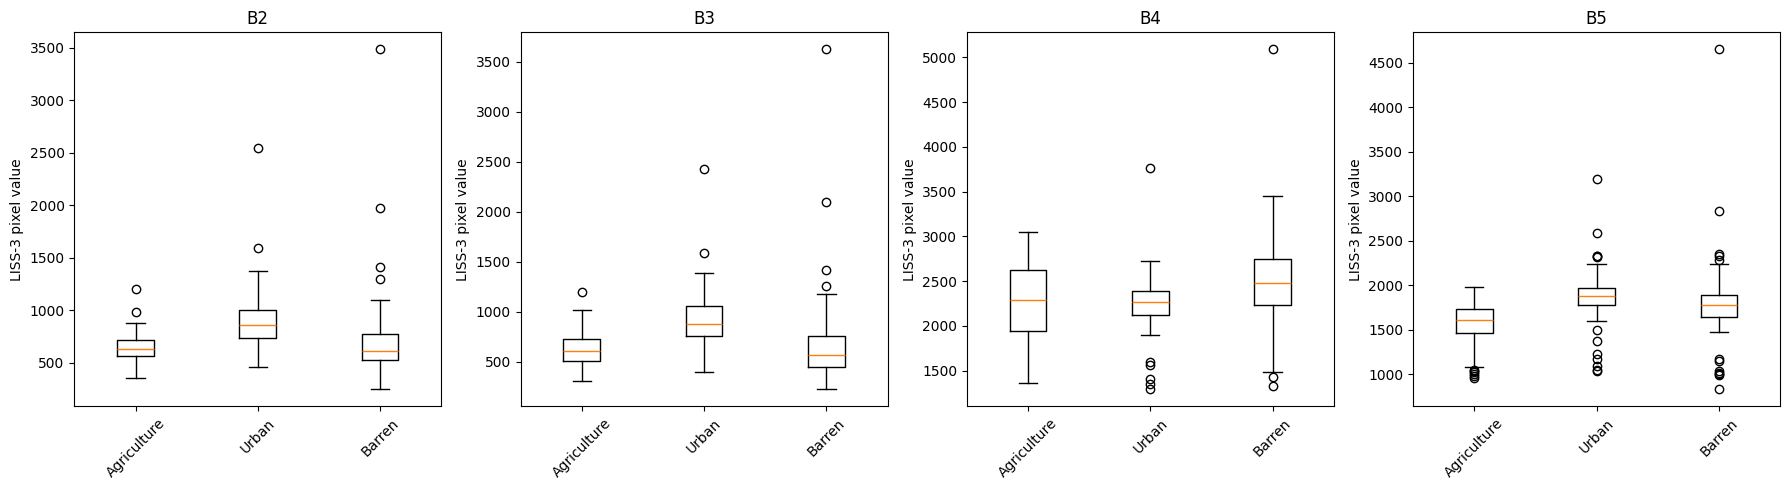

In [32]:
import matplotlib.pyplot as plt

plot_classes = {
    2: "Agriculture",
    4: "Urban",
    5: "Barren"
}

fig, axes = plt.subplots(
    1, 4,
    figsize=(18, 5)
)

for i, band in enumerate(["B2", "B3", "B4", "B5"]):

    data = []

    labels = []

    for class_id, class_name in plot_classes.items():

        values = samples_new[
            samples_new["class"] == class_id
        ][band]

        data.append(values)
        labels.append(class_name)

    axes[i].boxplot(
        data,
        tick_labels=labels
    )

    axes[i].set_title(band)
    axes[i].set_ylabel("LISS-3 pixel value")
    axes[i].tick_params(
        axis="x",
        rotation=45
    )

plt.tight_layout()
plt.show()

In [33]:
# Identify extreme samples in Agriculture, Urban and Barren

classes_to_check = [2, 4, 5]

for class_id in classes_to_check:

    print("\n" + "=" * 60)
    print(f"CLASS {class_id}")
    print("=" * 60)

    class_data = samples_new[
        samples_new["class"] == class_id
    ]

    # Show samples with unusually high values
    suspicious = class_data[
        (class_data["B2"] > 2000) |
        (class_data["B3"] > 2000) |
        (class_data["B4"] > 3500) |
        (class_data["B5"] > 3000)
    ]

    print(suspicious)
    print("\nNumber of suspicious samples:", len(suspicious))


CLASS 2
Empty DataFrame
Columns: [B2, B3, B4, B5, class]
Index: []

Number of suspicious samples: 0

CLASS 4
       B2    B3    B4    B5  class
381  2540  2429  3768  3199      4

Number of suspicious samples: 1

CLASS 5
       B2    B3    B4    B5  class
179  1976  2098  3446  2832      5
328  3483  3622  5090  4653      5

Number of suspicious samples: 2


In [34]:
suspicious_indices = [381, 179, 328]

suspicious_points = training_new.loc[
    suspicious_indices
].copy()

print(suspicious_points)

     classes                        geometry
381        4  POINT (221936.262 3365698.155)
179        5  POINT (232172.314 3344187.891)
328        5  POINT (203780.188 3373507.771)


In [35]:
print("\nCoordinates:")

for idx, row in suspicious_points.iterrows():
    print(
        f"Index {idx} | "
        f"Class {row['classes']} | "
        f"X = {row.geometry.x:.3f} | "
        f"Y = {row.geometry.y:.3f}"
    )


Coordinates:
Index 381 | Class 4 | X = 221936.262 | Y = 3365698.155
Index 179 | Class 5 | X = 232172.314 | Y = 3344187.891
Index 328 | Class 5 | X = 203780.188 | Y = 3373507.771


In [36]:
# Correct the mislabeled sample
training_new.loc[179, "classes"] = 5

# Update the corresponding ML dataset
samples_new.loc[179, "class"] = 5

# Verify
print("Corrected point 179:")
print(training_new.loc[179])

print("\nUpdated spectral record:")
print(samples_new.loc[179])

print("\nUpdated class distribution:")
print(samples_new["class"].value_counts().sort_index())

Corrected point 179:
classes                                                5
geometry    POINT (232172.3140881243 3344187.8909514034)
Name: 179, dtype: object

Updated spectral record:
B2       1976
B3       2098
B4       3446
B5       2832
class       5
Name: 179, dtype: int64

Updated class distribution:
class
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [37]:
import os
import geopandas as gpd

# Start from the current training points
final_training = training_new.copy()

# Add current spectral values
final_training["B2"] = samples_new["B2"].values
final_training["B3"] = samples_new["B3"].values
final_training["B4"] = samples_new["B4"].values
final_training["B5"] = samples_new["B5"].values

# Current verified class
final_training["class"] = samples_new["class"].astype(int)

# Keep required fields
final_training = final_training[
    ["B2", "B3", "B4", "B5", "class", "geometry"]
]

# Save corrected master GeoPackage
gpkg_path = os.path.join(
    base,
    "LISS3_Dehradun_Training_Data_516.gpkg"
)

final_training.to_file(
    gpkg_path,
    layer="training_samples",
    driver="GPKG"
)

print("GeoPackage updated successfully:")
print(gpkg_path)

print("\nShape:", final_training.shape)
print("CRS:", final_training.crs)

print("\nClass distribution:")
print(
    final_training["class"]
    .value_counts()
    .sort_index()
)

GeoPackage updated successfully:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_Training_Data_516.gpkg

Shape: (516, 6)
CRS: EPSG:32644

Class distribution:
class
1    110
2    104
3    100
4    101
5    101
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

# Use the verified master dataset
X = final_training[["B2", "B3", "B4", "B5"]]
y = final_training["class"]

# 10-fold stratified CV
cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Final Logistic Regression pipeline
final_model = Pipeline([
    (
        "poly",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logreg",
        LogisticRegression(
            C=100,
            class_weight=None,
            solver="lbfgs",
            max_iter=5000
        )
    )
])

# Cross-validation
scores = cross_val_score(
    final_model,
    X,
    y,
    cv=cv10,
    scoring="accuracy"
)

print("10-Fold Accuracy:")

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\nMean CV Accuracy:",
      f"{scores.mean() * 100:.2f}%")

print("Standard Deviation:",
      f"{scores.std() * 100:.2f}%")

print("Minimum Accuracy:",
      f"{scores.min() * 100:.2f}%")

print("Maximum Accuracy:",
      f"{scores.max() * 100:.2f}%")

10-Fold Accuracy:
Fold 1: 61.54%
Fold 2: 67.31%
Fold 3: 59.62%
Fold 4: 61.54%
Fold 5: 51.92%
Fold 6: 69.23%
Fold 7: 64.71%
Fold 8: 56.86%
Fold 9: 62.75%
Fold 10: 62.75%

Mean CV Accuracy: 61.82%
Standard Deviation: 4.72%
Minimum Accuracy: 51.92%
Maximum Accuracy: 69.23%


In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

standard_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=0.1,
        class_weight=None,
        solver="lbfgs",
        max_iter=5000
    ))
])

scores_standard = cross_val_score(
    standard_model,
    X,
    y,
    cv=cv10,
    scoring="accuracy"
)

print("Standard Logistic Regression")
print("--------------------------------")

for i, score in enumerate(scores_standard, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\nMean CV Accuracy:",
      f"{scores_standard.mean() * 100:.2f}%")

print("Standard Deviation:",
      f"{scores_standard.std() * 100:.2f}%")

Standard Logistic Regression
--------------------------------
Fold 1: 46.15%
Fold 2: 50.00%
Fold 3: 46.15%
Fold 4: 48.08%
Fold 5: 51.92%
Fold 6: 46.15%
Fold 7: 58.82%
Fold 8: 43.14%
Fold 9: 47.06%
Fold 10: 52.94%

Mean CV Accuracy: 49.04%
Standard Deviation: 4.30%


In [40]:
# Train final model using all 516 training samples

final_model.fit(X, y)

print("Final Polynomial Logistic Regression trained successfully.")

print("\nTraining samples:", len(X))
print("Features:", X.columns.tolist())

print("\nModel configuration:")
print("Polynomial degree: 2")
print("C: 100")
print("Solver: lbfgs")
print("Class weight: None")

Final Polynomial Logistic Regression trained successfully.

Training samples: 516
Features: ['B2', 'B3', 'B4', 'B5']

Model configuration:
Polynomial degree: 2
C: 100
Solver: lbfgs
Class weight: None


In [41]:
import rasterio

band_paths = {
    "B2": B2,
    "B3": B3,
    "B4": B4,
    "B5": B5
}

print("=" * 60)
print("DEHRADUN LISS-3 RASTER CHECK")
print("=" * 60)

for band_name, path in band_paths.items():

    with rasterio.open(path) as src:

        print(f"\n{band_name}")
        print("CRS:", src.crs)
        print("Width:", src.width)
        print("Height:", src.height)
        print("Resolution:", src.res)
        print("Data type:", src.dtypes[0])
        print("NoData:", src.nodata)
        print("Bounds:", src.bounds)

DEHRADUN LISS-3 RASTER CHECK

B2
CRS: EPSG:32644
Width: 2919
Height: 4792
Resolution: (24.0, 24.0)
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)

B3
CRS: EPSG:32644
Width: 2919
Height: 4792
Resolution: (24.0, 24.0)
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)

B4
CRS: EPSG:32644
Width: 2919
Height: 4792
Resolution: (24.0, 24.0)
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)

B5
CRS: EPSG:32644
Width: 2919
Height: 4792
Resolution: (24.0, 24.0)
Data type: uint16
NoData: None
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)


In [42]:
import numpy as np
import rasterio
import os

# Output classification raster
classification_path = os.path.join(
    base,
    "LISS3_Dehradun_LandCover_Classification.tif"
)

# Open all four bands
src_b2 = rasterio.open(B2)
src_b3 = rasterio.open(B3)
src_b4 = rasterio.open(B4)
src_b5 = rasterio.open(B5)

# Use B2 as reference raster
profile = src_b2.profile.copy()

# Classification raster will contain classes 1–5
profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw"
)

# Create output raster
with rasterio.open(
    classification_path,
    "w",
    **profile
) as dst:

    # Process raster in blocks
    for block_index, window in src_b2.block_windows(1):

        # Read the four bands
        b2 = src_b2.read(1, window=window)
        b3 = src_b3.read(1, window=window)
        b4 = src_b4.read(1, window=window)
        b5 = src_b5.read(1, window=window)

        # Create feature matrix
        pixels = np.column_stack([
            b2.ravel(),
            b3.ravel(),
            b4.ravel(),
            b5.ravel()
        ])

        # Valid pixels
        valid = np.all(
            np.isfinite(pixels),
            axis=1
        )

        predictions = np.zeros(
            pixels.shape[0],
            dtype=np.uint8
        )

        # Predict only valid pixels
        if np.any(valid):

            predictions[valid] = final_model.predict(
                pixels[valid]
            ).astype(np.uint8)

        # Restore block dimensions
        predictions = predictions.reshape(
            b2.shape
        )

        # Write classification block
        dst.write(
            predictions,
            1,
            window=window
        )

        print(
            f"Processed block: {block_index}"
        )

# Close input rasters
src_b2.close()
src_b3.close()
src_b4.close()
src_b5.close()

print("\n" + "=" * 60)
print("CLASSIFICATION COMPLETE")
print("=" * 60)
print("Output:")
print(classification_path)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processed block: (0, 0)
Processed block: (0, 1)
Processed block: (0, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processed block: (0, 3)
Processed block: (0, 4)
Processed block: (0, 5)
Processed block: (0, 6)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

Processed block: (17, 10)
Processed block: (17, 11)
Processed block: (18, 0)
Processed block: (18, 1)
Processed block: (18, 2)
Processed block: (18, 3)
Processed block: (18, 4)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

Processed block: (18, 5)
Processed block: (18, 6)
Processed block: (18, 7)
Processed block: (18, 8)
Processed block: (18, 9)
Processed block: (18, 10)
Processed block: (18, 11)

CLASSIFICATION COMPLETE
Output:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_LandCover_Classification.tif


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [43]:
import rasterio
import numpy as np

classification_path = "/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_LandCover_Classification.tif"

with rasterio.open(classification_path) as src:

    print("=" * 60)
    print("CLASSIFIED RASTER CHECK")
    print("=" * 60)

    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("Data type:", src.dtypes[0])
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)

    # Read classification
    classified = src.read(1)

    # Unique values and counts
    values, counts = np.unique(
        classified,
        return_counts=True
    )

    print("\nClass values and pixel counts:")

    for value, count in zip(values, counts):
        print(
            f"Class {value}: "
            f"{count:,} pixels"
        )

CLASSIFIED RASTER CHECK
CRS: EPSG:32644
Width: 2919
Height: 4792
Resolution: (24.0, 24.0)
Data type: uint8
NoData: 0.0
Bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)

Class values and pixel counts:
Class 1: 2,429,003 pixels
Class 2: 770,839 pixels
Class 3: 8,819,545 pixels
Class 4: 641,233 pixels
Class 5: 1,327,228 pixels


In [44]:
import rasterio
import numpy as np
import pandas as pd

classification_path = "/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_LandCover_Classification.tif"

class_names = {
    1: "Forest",
    2: "Agriculture",
    3: "Water",
    4: "Urban",
    5: "Barren"
}

with rasterio.open(classification_path) as src:

    classified = src.read(1)

    pixel_area_m2 = abs(src.res[0] * src.res[1])
    pixel_area_ha = pixel_area_m2 / 10000
    pixel_area_km2 = pixel_area_m2 / 1_000_000

    values, counts = np.unique(
        classified,
        return_counts=True
    )

    results = []

    for value, count in zip(values, counts):

        if value == 0:
            continue

        area_m2 = count * pixel_area_m2
        area_ha = count * pixel_area_ha
        area_km2 = count * pixel_area_km2

        results.append({
            "Class": int(value),
            "Land Cover": class_names.get(
                int(value),
                "Unknown"
            ),
            "Pixels": int(count),
            "Area_m2": area_m2,
            "Area_ha": area_ha,
            "Area_km2": area_km2
        })

area_df = pd.DataFrame(results)

print("=" * 70)
print("DEHRADUN LISS-3 LAND COVER AREA")
print("=" * 70)

print(
    area_df.to_string(
        index=False,
        formatters={
            "Area_m2": "{:,.2f}".format,
            "Area_ha": "{:,.2f}".format,
            "Area_km2": "{:,.4f}".format
        }
    )
)

print("\nPixel area:")
print(f"{pixel_area_m2:.2f} m²")

print("\nTotal classified area:")
print(
    f"{area_df['Area_km2'].sum():.4f} km²"
)

DEHRADUN LISS-3 LAND COVER AREA
 Class  Land Cover  Pixels          Area_m2    Area_ha   Area_km2
     1      Forest 2429003 1,399,105,728.00 139,910.57 1,399.1057
     2 Agriculture  770839   444,003,264.00  44,400.33   444.0033
     3       Water 8819545 5,080,057,920.00 508,005.79 5,080.0579
     4       Urban  641233   369,350,208.00  36,935.02   369.3502
     5      Barren 1327228   764,483,328.00  76,448.33   764.4833

Pixel area:
576.00 m²

Total classified area:
8057.0004 km²


In [45]:
import rasterio
import geopandas as gpd
import numpy as np

classification_path = "/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_LandCover_Classification.tif"

boundary_path = "/content/drive/MyDrive/Python Project/LISS3_Dehradun/Dehradun_boundary/Dehradun.shp"

# Load boundary
boundary = gpd.read_file(boundary_path)

print("Boundary CRS:", boundary.crs)
print("Boundary area:")
print(boundary.to_crs("EPSG:32644").geometry.area.sum() / 1e6, "km²")

# Check classified raster
with rasterio.open(classification_path) as src:

    print("\nRaster CRS:", src.crs)
    print("Raster bounds:", src.bounds)
    print("Raster area:",
          src.width * src.height *
          abs(src.res[0] * src.res[1]) / 1e6,
          "km²")

    classified = src.read(1)

    print("\nUnique values:")
    print(np.unique(classified, return_counts=True))

Boundary CRS: EPSG:4326
Boundary area:
3070.9991495864856 km²

Raster CRS: EPSG:32644
Raster bounds: BoundingBox(left=169709.94537568116, bottom=3316356.0, right=239765.94537568116, top=3431364.0)
Raster area: 8057.000448 km²

Unique values:
(array([1, 2, 3, 4, 5], dtype=uint8), array([2429003,  770839, 8819545,  641233, 1327228]))


In [46]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import os

classification_path = (
    "/content/drive/MyDrive/Python Project/"
    "LISS3_Dehradun/LISS3_Dehradun_LandCover_Classification.tif"
)

boundary_path = (
    "/content/drive/MyDrive/Python Project/"
    "LISS3_Dehradun/Dehradun_boundary/Dehradun.shp"
)

clipped_classification_path = (
    "/content/drive/MyDrive/Python Project/"
    "LISS3_Dehradun/"
    "LISS3_Dehradun_LandCover_Classification_Clipped.tif"
)

# ---------------------------------------------------------
# Load Dehradun boundary
# ---------------------------------------------------------
boundary = gpd.read_file(boundary_path)

# Reproject boundary to raster CRS
with rasterio.open(classification_path) as src:

    boundary_raster_crs = boundary.to_crs(src.crs)

    # Geometry for masking
    geometries = boundary_raster_crs.geometry.values

    # Mask raster to boundary
    clipped_image, clipped_transform = mask(
        src,
        geometries,
        crop=True,
        nodata=0
    )

    # Update raster metadata
    clipped_profile = src.profile.copy()

    clipped_profile.update({
        "height": clipped_image.shape[1],
        "width": clipped_image.shape[2],
        "transform": clipped_transform,
        "nodata": 0,
        "compress": "lzw"
    })

    # Save clipped classification
    with rasterio.open(
        clipped_classification_path,
        "w",
        **clipped_profile
    ) as dst:

        dst.write(clipped_image)

print("=" * 60)
print("CLASSIFIED RASTER CLIPPED TO DEHRADUN")
print("=" * 60)

print("Output:")
print(clipped_classification_path)

print("\nOriginal raster size:")
print(src.width, "x", src.height)

print("\nClipped raster size:")
print(clipped_image.shape[2], "x", clipped_image.shape[1])

print("\nCRS:")
print(clipped_profile["crs"])

print("\nResolution:")
print(clipped_profile["transform"].a,
      abs(clipped_profile["transform"].e))

CLASSIFIED RASTER CLIPPED TO DEHRADUN
Output:
/content/drive/MyDrive/Python Project/LISS3_Dehradun/LISS3_Dehradun_LandCover_Classification_Clipped.tif

Original raster size:
2919 x 4792

Clipped raster size:
2919 x 4792

CRS:
EPSG:32644

Resolution:
24.0 24.0


In [47]:
import rasterio
import numpy as np
import pandas as pd

clipped_path = (
    "/content/drive/MyDrive/Python Project/"
    "LISS3_Dehradun/"
    "LISS3_Dehradun_LandCover_Classification_Clipped.tif"
)

class_names = {
    1: "Forest",
    2: "Agriculture",
    3: "Water",
    4: "Urban",
    5: "Barren"
}

with rasterio.open(clipped_path) as src:

    classified = src.read(1)

    # Count every value, including NoData
    values, counts = np.unique(
        classified,
        return_counts=True
    )

    print("=" * 70)
    print("MASK VERIFICATION")
    print("=" * 70)

    for value, count in zip(values, counts):

        if value == 0:
            name = "NoData / Outside Boundary"
        else:
            name = class_names.get(
                int(value),
                "Unknown"
            )

        print(
            f"Value {value}: "
            f"{name} = {count:,} pixels"
        )

    # Pixel area
    pixel_area_m2 = abs(
        src.res[0] * src.res[1]
    )

    # ---------------------------------------------------------
    # Calculate only valid Dehradun pixels
    # ---------------------------------------------------------

    valid_mask = classified != 0

    valid_pixels = np.sum(valid_mask)

    print("\n" + "=" * 70)
    print("VALID DEHRADUN PIXELS")
    print("=" * 70)

    print("Valid pixels:", f"{valid_pixels:,}")
    print("NoData pixels:",
          f"{np.sum(classified == 0):,}")

    print(
        "Valid area:",
        f"{valid_pixels * pixel_area_m2 / 1e6:.4f} km²"
    )

    # ---------------------------------------------------------
    # Class areas
    # ---------------------------------------------------------

    results = []

    for class_id in range(1, 6):

        pixel_count = np.sum(
            classified == class_id
        )

        area_m2 = pixel_count * pixel_area_m2
        area_ha = area_m2 / 10000
        area_km2 = area_m2 / 1e6

        percentage = (
            pixel_count / valid_pixels * 100
        )

        results.append({
            "Class": class_id,
            "Land Cover": class_names[class_id],
            "Pixels": int(pixel_count),
            "Area_ha": area_ha,
            "Area_km2": area_km2,
            "Percentage": percentage
        })

area_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("FINAL DEHRADUN LAND COVER STATISTICS")
print("=" * 70)

print(
    area_df.to_string(
        index=False,
        formatters={
            "Area_ha": "{:,.2f}".format,
            "Area_km2": "{:,.4f}".format,
            "Percentage": "{:.2f}%".format
        }
    )
)

print("\nTotal classified area:")
print(
    f"{area_df['Area_km2'].sum():,.4f} km²"
)

print(
    f"{area_df['Percentage'].sum():.2f}%"
)

MASK VERIFICATION
Value 0: NoData / Outside Boundary = 8,656,245 pixels
Value 1: Forest = 2,429,003 pixels
Value 2: Agriculture = 770,839 pixels
Value 3: Water = 163,300 pixels
Value 4: Urban = 641,233 pixels
Value 5: Barren = 1,327,228 pixels

VALID DEHRADUN PIXELS
Valid pixels: 5,331,603
NoData pixels: 8,656,245
Valid area: 3071.0033 km²

FINAL DEHRADUN LAND COVER STATISTICS
 Class  Land Cover  Pixels    Area_ha   Area_km2 Percentage
     1      Forest 2429003 139,910.57 1,399.1057     45.56%
     2 Agriculture  770839  44,400.33   444.0033     14.46%
     3       Water  163300   9,406.08    94.0608      3.06%
     4       Urban  641233  36,935.02   369.3502     12.03%
     5      Barren 1327228  76,448.33   764.4833     24.89%

Total classified area:
3,071.0033 km²
100.00%
